Exploratory Data Analysis (EDA) - AI & DS Job Market 2025-2026

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
df = pd.read_csv('AI_Job_Market_Trends_2026.csv')
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [174]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [175]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


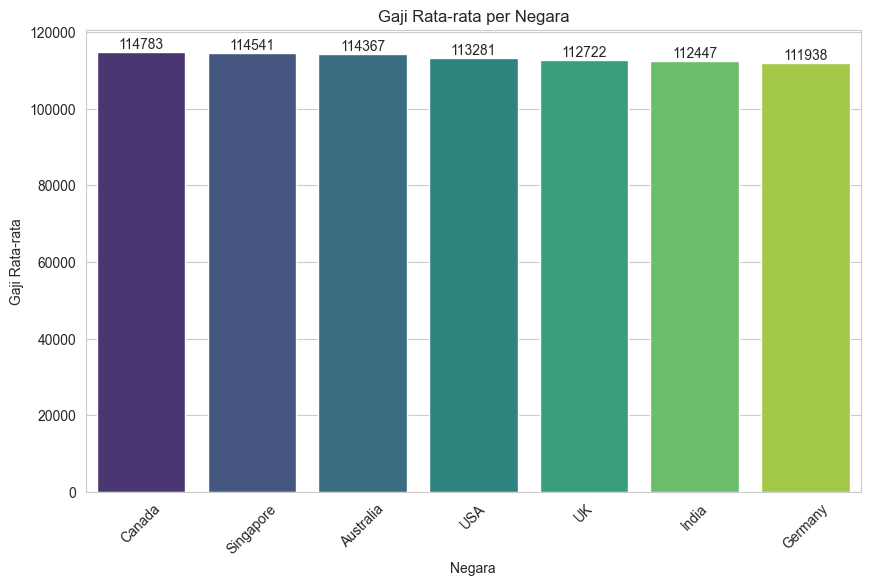

In [176]:
# Gaji rata-rata per negara
salary_by_country = df.groupby('country')['salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=salary_by_country.index, 
    y=salary_by_country.values, 
    hue=salary_by_country.index, 
    palette='viridis',
    legend=False
)

plt.title('Gaji Rata-rata per Negara')
plt.xlabel('Negara')
plt.ylabel('Gaji Rata-rata')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

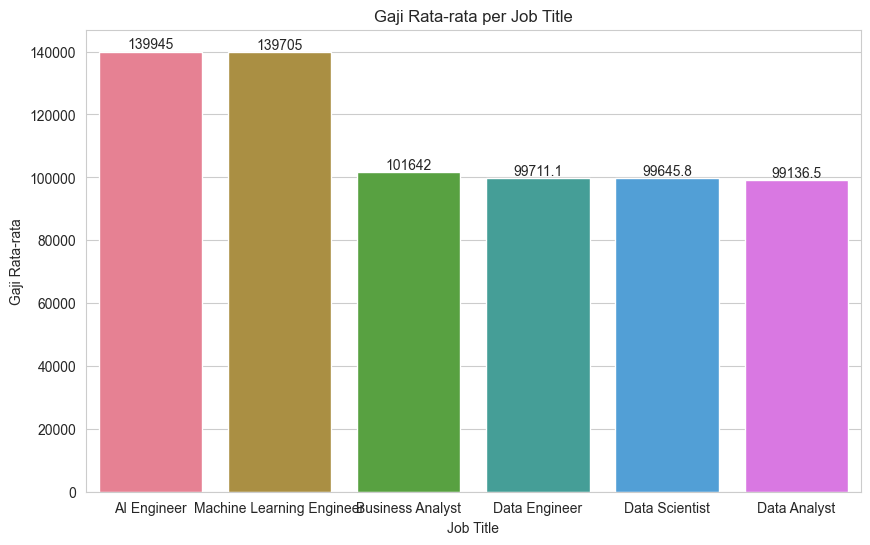

In [177]:
# Gaji rata-rata per job title
salary_by_job_title = df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=salary_by_job_title.index,
    y=salary_by_job_title.values,
    hue=salary_by_job_title.index,
    palette='husl'
)

plt.title('Gaji Rata-rata per Job Title')
plt.xlabel('Job Title')
plt.ylabel('Gaji Rata-rata')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

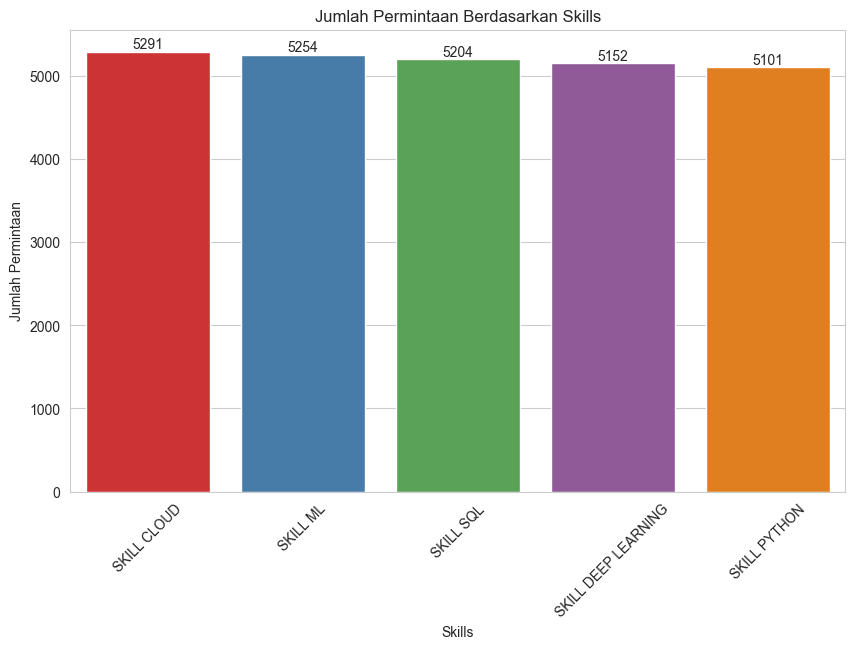

In [178]:
# Jumlah permintaan berdasarkan skills
skill_cols = [col for col in df.columns if col.startswith('skills_')]
skill_counts = df[skill_cols].sum().sort_values(ascending=False).head(10)
skill_counts.index = (
    skill_counts.index
    .str.replace('skills', 'skill')
    .str.replace('_', ' ')
    .str.upper()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=skill_counts.index, 
    y=skill_counts.values, 
    hue=skill_counts.index, 
    palette='Set1'
)

plt.title('Jumlah Permintaan Berdasarkan Skills')
plt.xlabel('Skills')
plt.ylabel('Jumlah Permintaan')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

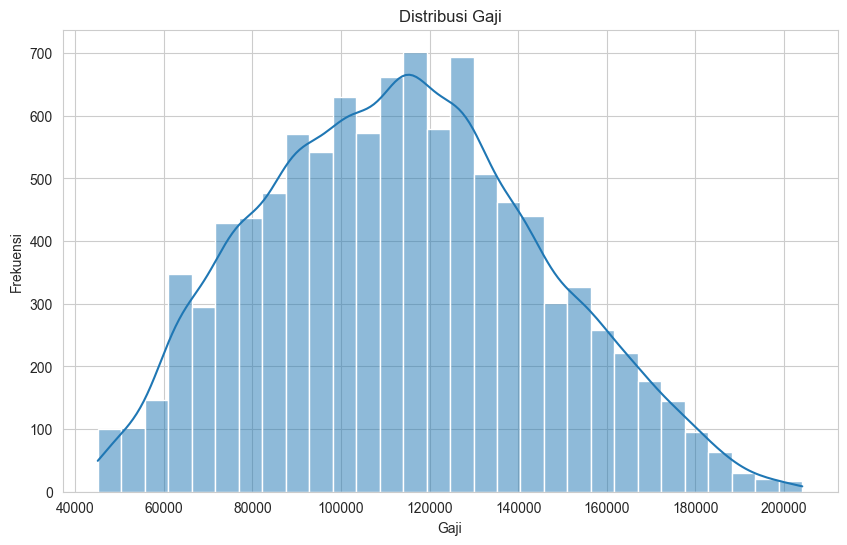

In [179]:
# Distribusi gaji
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Distribusi Gaji')
plt.xlabel('Gaji')
plt.ylabel('Frekuensi')
plt.show()

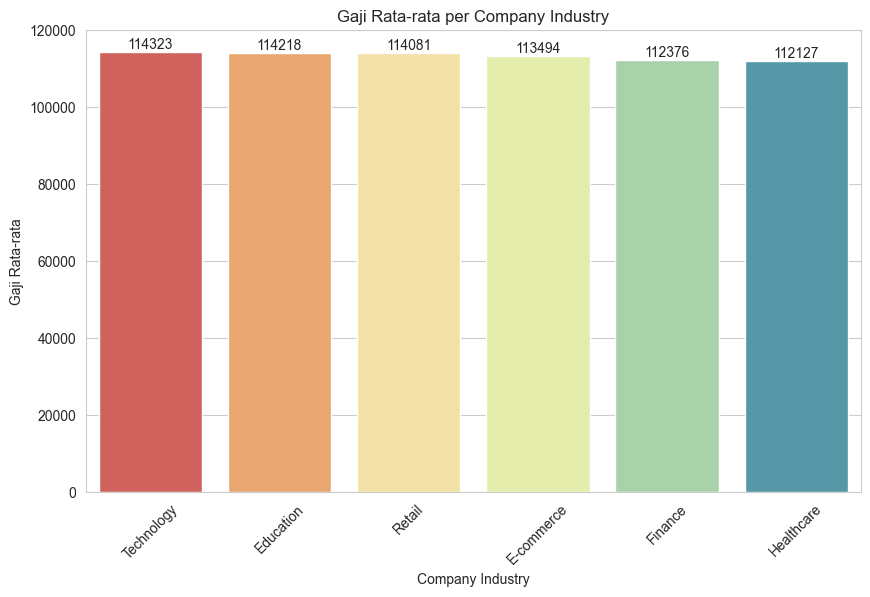

In [180]:
# Company Industry dengan gaji tertinggi
salary_by_country = df.groupby('company_industry')['salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=salary_by_country.index,
    y=salary_by_country.values,
    hue=salary_by_country.index,
    palette='Spectral',
)

plt.title('Gaji Rata-rata per Company Industry')
plt.xlabel('Company Industry')
plt.ylabel('Gaji Rata-rata')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

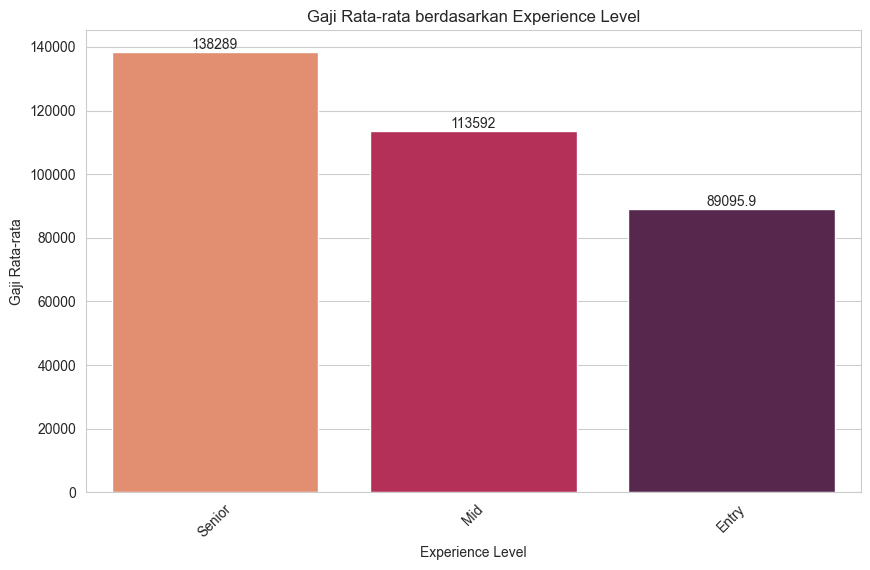

In [181]:
# Gaji rata-rata berdasarkan experience level
salary_by_experience = df.groupby('experience_level')['salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=salary_by_experience.index,
    y=salary_by_experience.values,
    hue=salary_by_experience.index,
    palette='rocket_r',
    legend=False
)

plt.title('Gaji Rata-rata berdasarkan Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Gaji Rata-rata')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

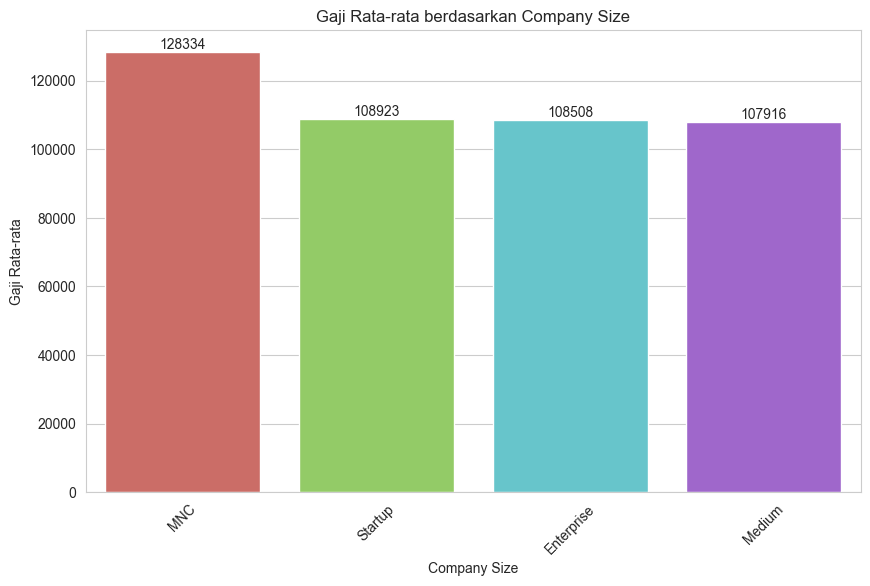

In [191]:
# Gaji rata-rata berdasarkan Company Size
salary_by_company_size = df.groupby('company_size')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=salary_by_company_size.index,
    y=salary_by_company_size.values,
    hue=salary_by_company_size.index,
    palette='hls'
)

plt.title('Gaji Rata-rata berdasarkan Company Size')
plt.xlabel('Company Size')
plt.ylabel('Gaji Rata-rata')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

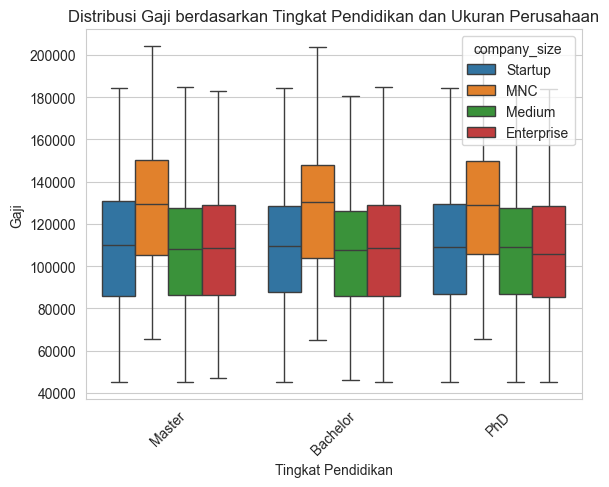

In [201]:
# Education level vs Company Size
sns.boxplot(x='education_level', y='salary', hue='company_size', data=df)

plt.title('Distribusi Gaji berdasarkan Tingkat Pendidikan dan Ukuran Perusahaan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Gaji')
plt.xticks(rotation=45)
plt.show()

Kesimpulan Analisis Data:
1. Berdasarkan negara, rata-rata gaji tertinggi terdapat di Canada sebesar 114,783, sedangkan yang terendah terdapat di Germany sebesar 111,938.
2. Berdasarkan job title, posisi dengan rata-rata gaji tertinggi adalah AI Engineer sebesar 139,945, sementara yang terendah adalah Data Analyst sebesar 99,136.5.
3. Berdasarkan permintaan skill, skill yang paling banyak dibutuhkan adalah cloud dengan total 5,291, sedangkan yang paling sedikit adalah python dengan total 5,101.
4. Distribusi gaji menunjukkan pola right-skewed, yang berarti sebagian besar data berada pada rentang gaji rendah, dengan sedikit data pada gaji yang sangat tinggi.
5. Berdasarkan industri perusahaan, rata-rata gaji tertinggi terdapat pada industri Technology sebesar 114,323, sedangkan yang terendah terdapat pada industri Healthcare sebesar 112,127.
6. Berdasarkan tingkat pengalaman, rata-rata gaji tertinggi terdapat pada level Senior sebesar 138,289, sementara level Entry memiliki rata-rata gaji terendah sebesar 89,096.
7. Berdasarkan ukuran perusahaan, Startup menawarkan rata-rata gaji tertinggi sebesar 128,334, sedangkan Enterprise memiliki rata-rata gaji terendah sebesar 107,916.
8. Berdasarkan tingkat pendidikan dan ukuran perusahaan, perusahaan bertipe MNC cenderung menawarkan gaji yang lebih tinggi dibandingkan tipe perusahaan lainnya di hampir semua tingkat pendidikan. Selain itu, perbedaan gaji antar tingkat pendidikan (Bachelor, Master, dan PhD) tidak menunjukkan perbedaan yang signifikan, sehingga mengindikasikan bahwa faktor lain seperti pengalaman dan keterampilan memiliki pengaruh yang lebih besar terhadap tingkat gaji.